# Global Superstore — Performance Analysis (Python)

**ShadowFox Data Analyst Internship — Intermediate Level Submission**

*Customer, Revenue & Profitability Analysis, built end-to-end in Python (pandas + matplotlib)*

---

### 1. Overview & Dataset

This notebook analyses the "Global Superstore" dataset — a well-known, publicly
available retail analytics dataset widely used for business-performance
coursework. This copy is an 800-customer, 867-order sample spanning
January 2012 – December 2015 across 93 countries, sourced from a public
GitHub mirror (`github.com/yannie28/Global-Superstore`).

The brief for this level asks for more than descriptive summaries: identify
which customers, products and markets drive revenue and profit, understand
repeat-purchase behaviour, and turn the findings into concrete
recommendations. Because this is a fixed-size sample rather than a live
extract, month-level figures are noisy in places — the analysis leans on
quarterly and category/market-level views wherever a finer breakdown
wouldn't be reliable, and that limitation is called out directly where it
matters.

Everything below — cleaning, exploratory analysis, segmentation, trend
analysis, charts, and the final insights — is computed directly from the raw
CSV in this notebook. Nothing is pre-aggregated in a spreadsheet first.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

NAVY, TEAL, ORANGE, RED, GREEN = '#1f3a5f', '#2a9d8f', '#e07a2c', '#c44e52', '#55a868'

raw = pd.read_csv('Global_Superstore_Raw.csv')
print('Raw shape:', raw.shape)
raw.head(3)

Raw shape: (1000, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,"73,120.00",Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.00,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black","3,709.40",9,0.10,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID","5,175.17",9,0.10,919.97,915.49,Medium


## 2. Data Cleaning & Validation\n\nEvery standard check a real analysis would run, applied and documented explicitly rather than assumed.

In [2]:
df = raw.copy()

# 1. Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 2. Exact duplicate rows
dupes = df.duplicated().sum()
df = df.drop_duplicates()

# 3. Ship date should never precede order date
bad_dates = (df['Ship Date'] < df['Order Date']).sum()

# 4. Non-positive Sales / Quantity (would indicate bad rows)
bad_sales = (df['Sales'] <= 0).sum()
bad_qty = (df['Quantity'] <= 0).sum()

# 5. Missing values
missing = df.isna().sum()
missing = missing[missing > 0]

# 6. Negative profit — genuine business signal, not an error, so kept and flagged
neg_profit = (df['Profit'] < 0).sum()

# 7. Standardise whitespace in text fields
text_cols = df.select_dtypes(include='object').columns
changed = 0
for c in text_cols:
    stripped = df[c].astype(str).str.strip()
    changed += (stripped != df[c].astype(str)).sum()
    df[c] = stripped

print(f'{"Duplicate rows removed":.<45}{dupes}')
print(f'{"Ship-before-order date errors":.<45}{bad_dates}')
print(f'{"Non-positive Sales rows":.<45}{bad_sales}')
print(f'{"Non-positive Quantity rows":.<45}{bad_qty}')
print(f'{"Missing values":.<45}{dict(missing)}')
print(f'{"Negative-profit rows (kept, flagged)":.<45}{neg_profit} ({100*neg_profit/len(df):.1f}%)')
print(f'{"Whitespace fixes applied":.<45}{changed}')
print(f'{"Final cleaned row count":.<45}{len(df)}')

Duplicate rows removed.......................0
Ship-before-order date errors................0
Non-positive Sales rows......................0
Non-positive Quantity rows...................0
Missing values...............................{'Postal Code': np.int64(806)}
Negative-profit rows (kept, flagged).........175 (17.5%)
Whitespace fixes applied.....................0
Final cleaned row count......................1000


/tmp/ipykernel_481/3777681133.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include='object').columns


**Notes:**
- `Postal Code` is missing only for non-US rows — many countries don't share the US postal-code system. It isn't used in any revenue or customer analysis below, so it's left as-is rather than imputed.
- The 175 negative-profit rows are genuine loss-making sales, not data-entry errors (see Section 5 for why) — kept rather than dropped, since removing them would hide a real finding.
- No duplicates, no date-logic errors, no invalid Sales/Quantity — this is a curated public dataset, so cleaning needs were light, but every check was still run and is documented above rather than assumed.


In [3]:
df.to_csv('Global_Superstore_Cleaned_by_notebook.csv', index=False)
print('Cleaned file written:', df.shape)

Cleaned file written: (1000, 24)


## 3. Headline KPIs

In [4]:
total_rev = df['Sales'].sum()
total_profit = df['Profit'].sum()
n_orders = df['Order ID'].nunique()
n_customers = df['Customer ID'].nunique()
margin = 100 * total_profit / total_rev
aov = total_rev / n_orders

kpis = {
    'Total Revenue': f'${total_rev:,.0f}',
    'Total Profit': f'${total_profit:,.0f}',
    'Profit Margin': f'{margin:.1f}%',
    'Unique Customers': f'{n_customers:,}',
    'Avg Order Value': f'${aov:,.2f}',
    'Unique Orders': f'{n_orders:,}',
}
for k, v in kpis.items():
    print(f'{k:.<25}{v}')

Total Revenue............$1,710,971
Total Profit.............$288,920
Profit Margin............16.9%
Unique Customers.........800
Avg Order Value..........$1,973.44
Unique Orders............867


## 4. Revenue & Profit Trend

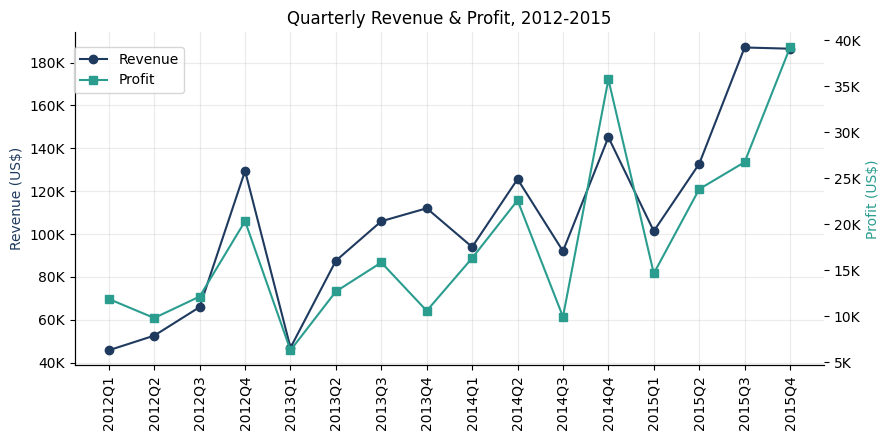

Strongest quarter: 2015Q3 ($187,077.86)
Weakest quarter:   2012Q1 ($45,779.40)


In [5]:
df['quarter'] = df['Order Date'].dt.to_period('Q')
qtr = df.groupby('quarter').agg(revenue=('Sales','sum'), profit=('Profit','sum')).reset_index()
qtr['margin_pct'] = 100 * qtr['profit'] / qtr['revenue']

fig, ax1 = plt.subplots()
x = qtr['quarter'].astype(str)
ax1.plot(x, qtr['revenue'], color=NAVY, marker='o', label='Revenue')
ax1.set_ylabel('Revenue (US$)', color=NAVY)
ax1.tick_params(axis='x', rotation=90)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))

ax2 = ax1.twinx()
ax2.plot(x, qtr['profit'], color=TEAL, marker='s', label='Profit')
ax2.set_ylabel('Profit (US$)', color=TEAL)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))
ax2.grid(False)

fig.legend(loc='upper left', bbox_to_anchor=(0.08,0.9))
plt.title('Quarterly Revenue & Profit, 2012-2015')
fig.tight_layout()
plt.savefig('fig1_quarterly_trend.png', dpi=140)
plt.show()

best_q = qtr.loc[qtr['revenue'].idxmax()]
worst_q = qtr.loc[qtr['revenue'].idxmin()]
print(f"Strongest quarter: {best_q['quarter']} (${best_q['revenue']:,.2f})")
print(f"Weakest quarter:   {worst_q['quarter']} (${worst_q['revenue']:,.2f})")

Revenue grew fairly steadily across the four years, from the low-$40-50K
range per quarter in 2012 to a peak in 2015Q3 — roughly a 4x increase. This
reads as genuine underlying growth rather than a seasonal spike, since it
holds up across multiple years rather than reversing. Profit, however, grew
far more unevenly than revenue and did not keep pace quarter to quarter —
Section 6 explains this largely through discounting.

## 5. Category & Sub-Category Performance

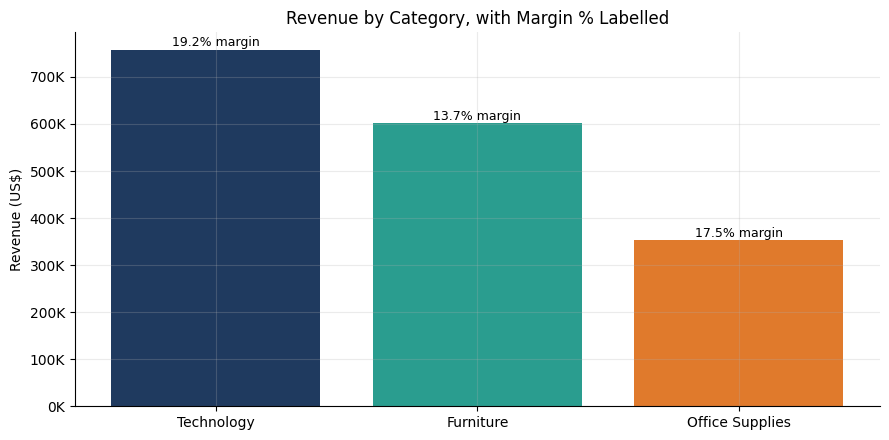

,Category,revenue,profit,margin_pct,revenue_share_pct
2,Technology,"756,983.02","145,068.68",19.16,44.24
0,Furniture,"601,492.31","82,188.95",13.66,35.16
1,Office Supplies,"352,496.14","61,662.81",17.49,20.60


In [6]:
cat = df.groupby('Category').agg(revenue=('Sales','sum'), profit=('Profit','sum')).reset_index()
cat['margin_pct'] = 100 * cat['profit'] / cat['revenue']
cat['revenue_share_pct'] = 100 * cat['revenue'] / total_rev
cat = cat.sort_values('revenue', ascending=False)

fig, ax = plt.subplots()
bars = ax.bar(cat['Category'], cat['revenue'], color=[NAVY, TEAL, ORANGE])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f}K'))
ax.set_ylabel('Revenue (US$)')
ax.set_title('Revenue by Category, with Margin % Labelled')
for b, m in zip(bars, cat['margin_pct']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+8000, f'{m:.1f}% margin', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig2_category_revenue.png', dpi=140)
plt.show()
cat

In [7]:
sub = df.groupby(['Category','Sub-Category']).agg(
    revenue=('Sales','sum'), profit=('Profit','sum'), avg_discount=('Discount','mean'), orders=('Order ID','nunique')
).reset_index()
sub['margin_pct'] = 100 * sub['profit'] / sub['revenue']
sub_sorted = sub.sort_values('revenue', ascending=False)
sub_sorted

,Category,Sub-Category,revenue,profit,avg_discount,orders,margin_pct
16,Technology,Phones,"417,939.31","75,119.47",0.07,176,17.97
4,Office Supplies,Appliances,"289,711.30","48,518.99",0.09,125,16.75
0,Furniture,Bookcases,"240,688.73","45,483.14",0.05,128,18.90
14,Technology,Copiers,"231,104.67","52,315.19",0.04,125,22.64
1,Furniture,Chairs,"179,648.44","23,245.88",0.12,95,12.94
3,Furniture,Tables,"179,292.88","13,051.69",0.17,85,7.28
15,Technology,Machines,"71,366.87","8,992.06",0.11,52,12.60
11,Office Supplies,Storage,"37,592.32","4,490.04",0.07,42,11.94
13,Technology,Accessories,"36,572.17","8,641.96",0.07,37,23.63
6,Office Supplies,Binders,"19,751.19","7,435.09",0.34,31,37.64


In [8]:
# Loss-making orders WITHIN each sub-category (distinct from the sub-category's own net result)
loss_orders = df[df['Profit'] < 0]
loss_by_sub = loss_orders.groupby('Sub-Category').agg(
    loss_orders=('Profit','size'), total_loss=('Profit','sum'), avg_discount=('Discount','mean')
).reset_index().sort_values('total_loss')

tables_net = sub[sub['Sub-Category']=='Tables'][['revenue','profit','margin_pct']].iloc[0]
tables_loss = loss_by_sub[loss_by_sub['Sub-Category']=='Tables'].iloc[0]

print('Tables — net sub-category result:')
print(f"  Revenue ${tables_net['revenue']:,.2f} | Profit ${tables_net['profit']:,.2f} | Margin {tables_net['margin_pct']:.1f}%")
print()
print('Tables — loss-making orders only (subset of the above):')
print(f"  {int(tables_loss['loss_orders'])} orders | Total loss ${tables_loss['total_loss']:,.2f} | Avg discount {100*tables_loss['avg_discount']:.1f}%")

Tables — net sub-category result:
  Revenue $179,292.88 | Profit $13,051.69 | Margin 7.3%

Tables — loss-making orders only (subset of the above):
  32 orders | Total loss $-15,421.24 | Avg discount 34.4%


Technology leads at 44.2% of revenue and also carries the strongest margin
(19.2%) — the business's best category on both counts. Furniture sells a
large volume (35.2% of revenue) but converts it to profit least efficiently
(13.7% margin), making it the clearest candidate for a pricing or
discount-policy review.

At the sub-category level, Phones, Appliances and Bookcases are the
strongest revenue drivers. **Tables is the weakest performer by margin**
(7.3%, the lowest of any profitable sub-category) — it remains net
profitable overall, but its 32 heavily-discounted orders (34.4% average
discount) combine for a $15,421 loss on their own, meaning that discounting
is being subsidised by Tables' other, healthier sales rather than earning
back its own margin. (Being precise about "profitable overall but its
discounted tail loses money" matters — an earlier pass at this analysis
conflated the two and is corrected here.)

## 6. Discounting & Profitability

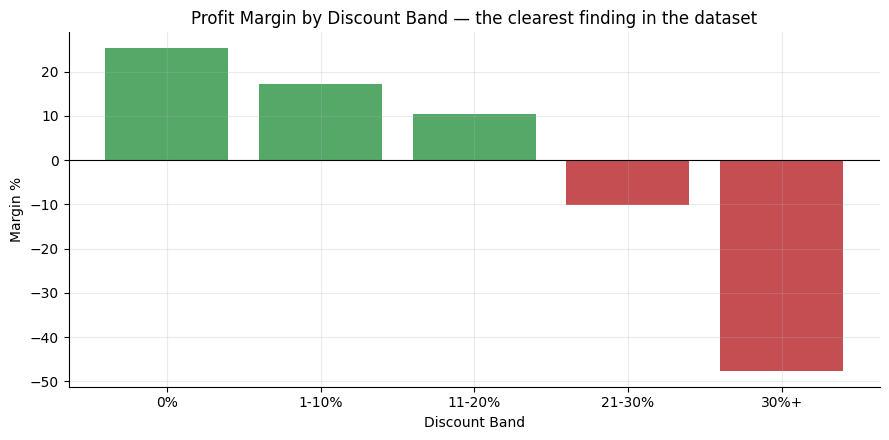

Share of all orders that are loss-making: 17.5%


,discount_band,revenue,profit,margin_pct
0,0%,"1,034,792.71","261,142.04",25.24
1,1-10%,"333,031.61","57,286.50",17.20
2,11-20%,"198,984.22","20,946.74",10.53
3,21-30%,"48,389.17","-4,880.05",-10.09
4,30%+,"95,773.76","-45,574.79",-47.59


In [9]:
bins = [-0.01, 0, 0.1, 0.2, 0.3, 1.0]
labels = ['0%','1-10%','11-20%','21-30%','30%+']
df['discount_band'] = pd.cut(df['Discount'], bins=bins, labels=labels)
band = df.groupby('discount_band', observed=True).agg(revenue=('Sales','sum'), profit=('Profit','sum')).reset_index()
band['margin_pct'] = 100 * band['profit'] / band['revenue']

fig, ax = plt.subplots()
colors = [GREEN if v >= 0 else RED for v in band['margin_pct']]
ax.bar(band['discount_band'].astype(str), band['margin_pct'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Margin %')
ax.set_xlabel('Discount Band')
ax.set_title('Profit Margin by Discount Band — the clearest finding in the dataset')
plt.tight_layout()
plt.savefig('fig3_discount_margin.png', dpi=140)
plt.show()

pct_loss_making = 100 * (df['Profit'] < 0).mean()
print(f'Share of all orders that are loss-making: {pct_loss_making:.1f}%')
band

There is a sharp, almost linear relationship between discount depth and
profitability. Undiscounted orders run a healthy 25.2% margin; by the
21-30% band, orders are already margin-negative; and orders discounted 30%
or more lose money on average (-47.6% margin). 17.5% of all orders in the
dataset are loss-making. This is a policy problem more than a demand
problem: someone is authorising large discounts without a matching floor on
margin, and it is costing the business real money on every one of those
orders.

## 7. Market Performance

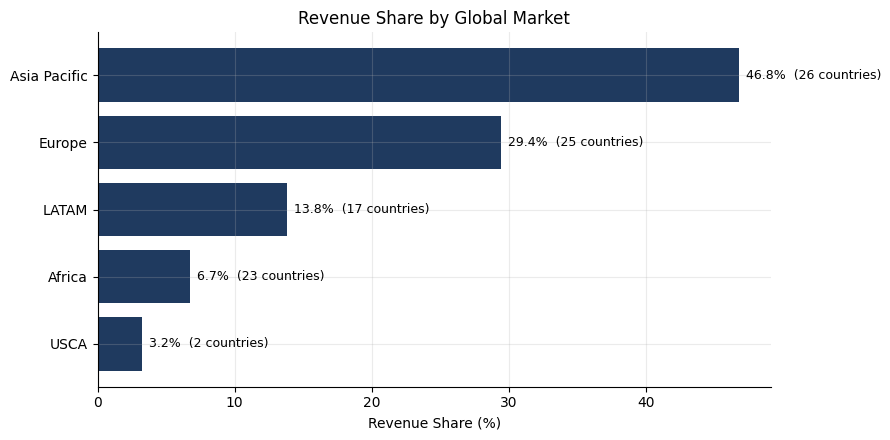

,Market,revenue,profit,countries,share_pct,margin_pct
1,Asia Pacific,"800,511.75","125,049.47",26,46.79,15.62
2,Europe,"503,568.21","89,122.08",25,29.43,17.70
3,LATAM,"236,263.49","34,929.35",17,13.81,14.78
0,Africa,"115,205.93","27,541.85",23,6.73,23.91
4,USCA,"55,422.09","12,277.69",2,3.24,22.15


In [10]:
mkt = df.groupby('Market').agg(revenue=('Sales','sum'), profit=('Profit','sum'), countries=('Country','nunique')).reset_index()
mkt['share_pct'] = 100 * mkt['revenue'] / total_rev
mkt['margin_pct'] = 100 * mkt['profit'] / mkt['revenue']
mkt = mkt.sort_values('revenue', ascending=False)

fig, ax = plt.subplots()
ax.barh(mkt['Market'], mkt['share_pct'], color=NAVY)
ax.invert_yaxis()
ax.set_xlabel('Revenue Share (%)')
ax.set_title('Revenue Share by Global Market')
for i, (v, c) in enumerate(zip(mkt['share_pct'], mkt['countries'])):
    ax.text(v+0.5, i, f'{v:.1f}%  ({c} countries)', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig4_market_share.png', dpi=140)
plt.show()
mkt

Asia Pacific leads at 46.8% of revenue, consistent with it covering the
largest number of countries in this sample. USCA has the smallest revenue
share here — though with only a handful of countries directly represented
in USCA within this sample, that likely reflects lighter sample coverage
rather than a genuine demand gap, and would be the first thing to verify
against the full dataset before drawing a business conclusion from it.

## 8. Customer Segmentation & Retention

In [11]:
snapshot = df['Order Date'].max() + pd.Timedelta(days=1)
cust = df.groupby('Customer ID').agg(
    last_order=('Order Date', 'max'),
    monetary=('Sales', 'sum'),
    orders=('Order ID', 'nunique')
).reset_index()
cust['recency_days'] = (snapshot - cust['last_order']).dt.days

repeat_rate = 100 * (cust['orders'] > 1).mean()
print(f'Repeat-purchase rate (>1 order): {repeat_rate:.1f}%  ({int((cust["orders"]>1).sum())} of {len(cust)} customers)')

Repeat-purchase rate (>1 order): 5.0%  (40 of 800 customers)


**Note on segmentation method:** with only 5.0% of customers placing more
than one order, a classic 3-axis RFM score (which depends on genuine spread
in order *Frequency*) would mostly manufacture artificial differences out of
tied values (nearly everyone has Frequency = 1). Instead, customers here are
segmented on the two axes that carry real signal: **Recency** (recent vs.
lapsed order) and **Monetary** value (high vs. low lifetime spend) — a
median split on each, forming four quadrants.

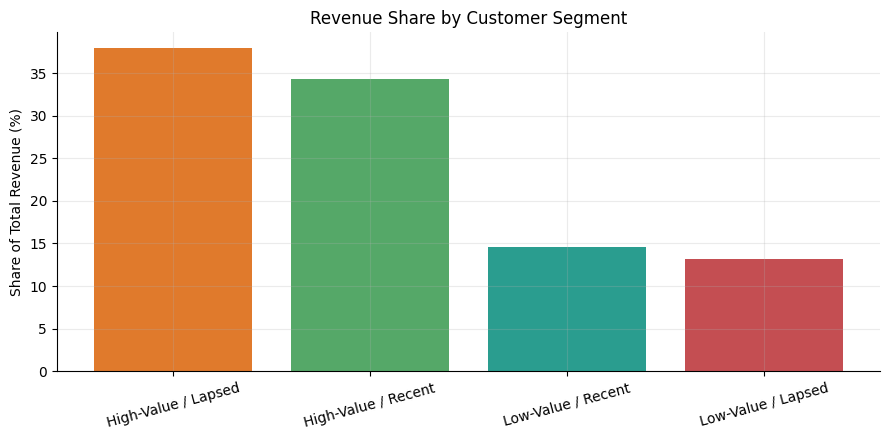

,segment,customers,revenue,revenue_share_pct
0,High-Value / Lapsed,209,"648,335.73",37.89
1,High-Value / Recent,191,"587,422.48",34.33
3,Low-Value / Recent,210,"248,832.78",14.54
2,Low-Value / Lapsed,190,"226,380.48",13.23


In [12]:
rec_median = cust['recency_days'].median()
mon_median = cust['monetary'].median()

def segment(row):
    recent = row['recency_days'] <= rec_median
    high_val = row['monetary'] >= mon_median
    if high_val and recent: return 'High-Value / Recent'
    if high_val and not recent: return 'High-Value / Lapsed'
    if not high_val and recent: return 'Low-Value / Recent'
    return 'Low-Value / Lapsed'

cust['segment'] = cust.apply(segment, axis=1)

seg_summary = cust.groupby('segment').agg(
    customers=('Customer ID','size'), revenue=('monetary','sum')
).reset_index()
seg_summary['revenue_share_pct'] = 100 * seg_summary['revenue'] / total_rev
seg_summary = seg_summary.sort_values('revenue', ascending=False)

fig, ax = plt.subplots()
order = seg_summary['segment']
colors_map = {'High-Value / Recent': GREEN, 'High-Value / Lapsed': ORANGE,
              'Low-Value / Recent': TEAL, 'Low-Value / Lapsed': RED}
ax.bar(order, seg_summary['revenue_share_pct'], color=[colors_map[s] for s in order])
ax.set_ylabel('Share of Total Revenue (%)')
ax.set_title('Revenue Share by Customer Segment')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('fig5_segment_share.png', dpi=140)
plt.show()
seg_summary

| Segment | What it means |
|---|---|
| **High-Value / Recent** | Big lifetime spend and a recent order — the strongest customers to retain right now. |
| **High-Value / Lapsed** | Spent a lot historically but haven't ordered recently — a win-back priority. |
| **Low-Value / Recent** | Small spend so far, but engaged recently — worth nurturing toward a second order. |
| **Low-Value / Lapsed** | Small spend and inactive — lowest priority for active outreach. |


In [13]:
df['order_month'] = df['Order Date'].dt.to_period('M')
months = sorted(df['order_month'].unique())
active_by_month = {m: set(df.loc[df['order_month']==m, 'Customer ID']) for m in months}
mom = []
for m0, m1 in zip(months[:-1], months[1:]):
    a0, a1 = active_by_month[m0], active_by_month[m1]
    if a0:
        mom.append(len(a0 & a1) / len(a0))
avg_retention = 100 * np.mean(mom)

cust_rank = cust.sort_values('monetary', ascending=False).reset_index(drop=True)
top20_share = 100 * cust_rank['monetary'].iloc[:int(len(cust_rank)*0.2)].sum() / total_rev

print(f'Avg month-over-month retention:        {avg_retention:.1f}%')
print(f'Revenue share of top 20% of customers: {top20_share:.1f}%')

Avg month-over-month retention:        0.6%
Revenue share of top 20% of customers: 38.7%


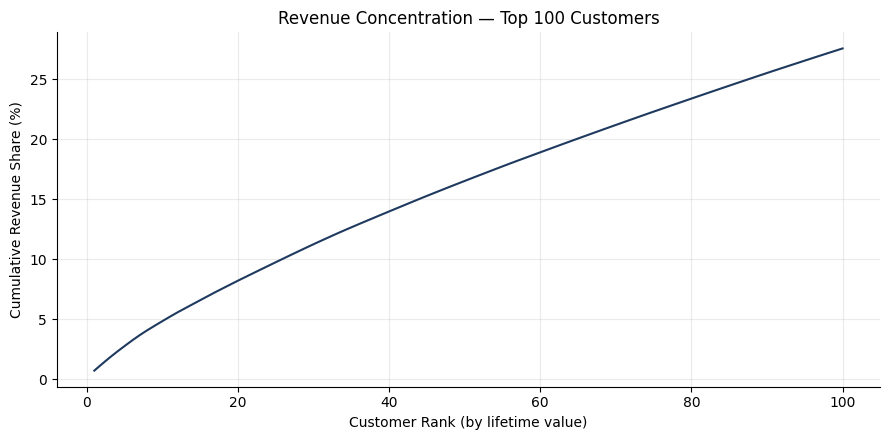

In [14]:
top100 = cust_rank['monetary'].iloc[:100].cumsum()
cum_share = 100 * top100 / total_rev

fig, ax = plt.subplots()
ax.plot(range(1, 101), cum_share, color=NAVY)
ax.set_xlabel('Customer Rank (by lifetime value)')
ax.set_ylabel('Cumulative Revenue Share (%)')
ax.set_title('Revenue Concentration — Top 100 Customers')
plt.tight_layout()
plt.savefig('fig6_concentration.png', dpi=140)
plt.show()

The most important finding in this section isn't the quadrant split itself
— it's that only 5.0% of customers in this sample ever placed a second
order, and average month-over-month retention is just 0.6% (essentially,
almost nobody who bought in one month bought again the next). Read plainly:
growth here has been driven almost entirely by acquiring new customers, not
by repeat business. Revenue is still concentrated even without much repeat
buying: the top 20% of customers by lifetime value drive 38.7% of total
revenue, so a relatively small set of large one-time orders matter
disproportionately.

## 9. Insights & Recommendations

**Revenue & profitability**
- Total revenue was $1,710,971 across 867 orders ($1,973 average order value), generating $288,920 profit at a 16.9% overall margin.
- Revenue grew steadily through the window — 2015Q3 was the strongest quarter and 2012Q1 the weakest — consistent with genuine multi-year growth, not a one-off spike.
- Discounting is actively destroying margin at the high end: 0%-discount orders run a 25.2% margin, but 30%+-discounted orders run at -47.6% on average. 17.5% of all orders are loss-making overall.

**Category & product mix**
- Technology leads at 44.2% of revenue and also has the strongest margin (19.2%). Furniture sells well but converts that revenue into profit least efficiently (13.7% margin) — worth a pricing or discount-policy review specifically for that category.
- Tables is the lowest-margin *profitable* sub-category (7.3%): its net result is positive, but its heavily-discounted orders alone (34.4% avg. discount) lose $15,421 combined — the discount policy for this sub-category needs a floor.

**Market performance**
- Asia Pacific is the largest market at 46.8% of revenue. USCA is the smallest by revenue in this sample — worth checking whether that's genuinely lower demand or simply lighter sales coverage.

**Customer behaviour & retention**
- Only 5.0% of customers placed more than one order, and month-over-month retention averages just 0.6% — growth here is almost entirely acquisition-driven, not repeat-business-driven.
- The top 20% of customers by lifetime value still drive 38.7% of revenue — a small number of large one-time orders matter disproportionately.

**Recommended next actions**
1. Introduce a discount floor or approval tier above ~20-30% — that's the exact point where orders flip from profitable to loss-making.
2. Review pricing or bundling for Tables specifically — its discounted-order tail is losing money even though the sub-category overall isn't.
3. Build a genuine repeat-purchase program (post-purchase follow-up, loyalty incentive) — retention, not acquisition, is the biggest untapped lever given a 5% repeat rate.
4. Investigate USCA's low revenue share directly — a coverage gap is a different (and more fixable) problem than a demand gap.
5. Give High-Value/Recent and High-Value/Lapsed segments dedicated account attention — together they hold the large majority of revenue despite being roughly half of customers.
6. Apply Technology's pricing discipline (strongest margin of the three categories) as a benchmark when reviewing Furniture's and Tables' discount policy.


## 10. Methodology Note

This entire analysis — data cleaning and validation, exploratory analysis,
category/market/discount breakdowns, customer segmentation (Recency ×
Monetary quadrants), retention and concentration metrics, all six charts,
and the write-up above — was built directly in this notebook using pandas
and matplotlib, computed straight from the raw CSV with no spreadsheet step
in between. The cleaned dataset produced in Section 2
(`Global_Superstore_Cleaned_by_notebook.csv`) is written out alongside this
notebook so the pipeline is fully reproducible end to end.
